<a href="https://colab.research.google.com/github/orchid-initiative/postpartum-larc/blob/main/analysis/larc_analysis_presentation_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [10]:
# connect the collab notebook to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# load the data from google drive
larc_dataset = pd.read_csv("/content/drive/MyDrive/Immediate Post-Partum LARC Utilization/sample aggregations/labor_and_delivery_SUMMARY_2024_20240703.csv")

In [12]:
# define the global variable with the types of larcs
larc_columns = {
    "larc": "Total LARC",
    "larc_uterine": "Uterine LARC",
    "larc_subcutaneous": "Subcutaneous LARC",
}

In [13]:
def larc_stats(demographic, df, larc_columns):
  '''collate statistics for the selected demographic'''

  cols = ["l_and_d_incl"] + list(larc_columns.keys())

  return(
      df.groupby(demographic)[cols]
      .sum()
  )

In [14]:
def relative_larc_rate(stat, stat_larc):
  '''take the dictionaries of the stat and the stat larc numbers and return a
     dictionary with the percentage values of the larc rate'''
  result = {key: (val * 100) / stat[key] for key, val in stat_larc.items()}

  return(result)

In [15]:
# collect results by hospital name
stats_df = larc_stats("hospital_name", larc_dataset, larc_columns)
hospital_name = stats_df["l_and_d_incl"].to_dict()
hospital_name_larc = stats_df["larc"].to_dict()
hospital_name_larc_rates = relative_larc_rate(hospital_name, hospital_name_larc)

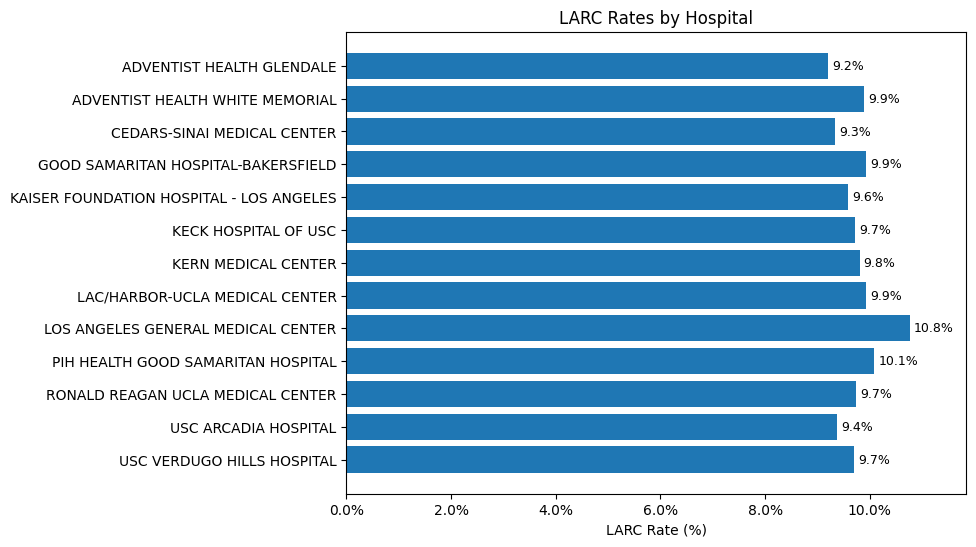

In [16]:
# initialize plot
fig, ax = plt.subplots(figsize = (8, 6))

# sort data alphabetically by hospital name
sorted_data = dict(sorted(hospital_name_larc_rates.items(),
                          key = lambda x: x[0],
                          reverse = True))
names = list(sorted_data.keys())
values = list(sorted_data.values())

sorted_data = sorted(hospital_name_larc_rates.items(), reverse = True)
names = [name for name, _ in sorted_data]
values = [value for _, value in sorted_data]

# plot the values as horizontal bars
bars = ax.barh(names, values)

# set titles and axis labels
ax.set_title("LARC Rates by Hospital")
ax.set_xlabel("LARC Rate (%)")

# set the axis ticks to display as percentages
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

# adjust the right margin for visibility
ax.set_xlim(0, max(values) * 1.1)

# add labels to bars
ax.bar_label(bars,
             fmt = "%.1f%%",
             padding = 3,
             fontsize = 9)

plt.show()

In [17]:
# get the by-year larc rate for each hospital
df_grouped = larc_dataset.groupby(by = ["dsch_yr", "hospital_name"])[["l_and_d_incl", "larc"]].sum()

# add the larc rate (in %) to the dataset
df_grouped["larc_rate"] = df_grouped["larc"] / df_grouped["l_and_d_incl"]
# filter for values after 2015 as earlier year data is poor quality
df_grouped = df_grouped[df_grouped.index.get_level_values("dsch_yr") >= 2015]


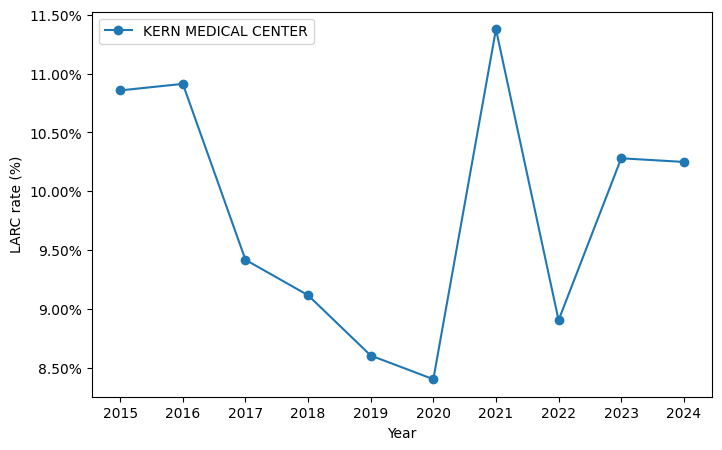

In [18]:
# reset the indicies and column labels for ease of use
plot_df = df_grouped.reset_index()

# select one hospital as an example - using all hospitals is too cluttered
hospital = "KERN MEDICAL CENTER"
hospital_df = plot_df[plot_df["hospital_name"] == hospital]

# initialize graph
fig, ax = plt.subplots(figsize = (8, 5))

# plot the values as a line graph
ax.plot(
    hospital_df["dsch_yr"],
    hospital_df["larc_rate"],
    marker = "o",
    label = hospital
)

# make sure there is an x axis label for every year
years = sorted(plot_df["dsch_yr"].unique())
ax.set_xticks(years)
ax.set_xlabel("Year")

# display the y axis label in %
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylabel("LARC rate (%)")

# display the legend
ax.legend()

# display graph
plt.show()

In [19]:
# get the LARC counts and statistics for the racial demographics
stats_df = larc_stats("race1", larc_dataset, larc_columns)
race = stats_df["l_and_d_incl"].to_dict()
race_larc = stats_df["larc"].to_dict()
race_larc_rate = relative_larc_rate(race, race_larc)

In [20]:
# lookup table for the racial demographics
race_lookup = {
    "R1": "American Indian or Alaska Native",
    "R2": "Asian",
    "R3": "Black or African American",
    "R4": "Native Hawaiian or Other Pacific Islander",
    "R5": "White",
    "R9": "Other Race"
}

In [21]:
# lookup table for ethnicities
ethnicity_lookup = {
    "E1": "Hispanic or Latino",
    "E2": "Non-Hispanic or Latino"
}

In [22]:
def demographic_table(demographic, demographic_name, dataset, larc_columns, lookup_table = None):
  '''take in the dataset and create a formatted table for the indicated demographic'''

  table = larc_stats(demographic, dataset, larc_columns).reset_index()

  # rename the demographic and delivery columns
  table = table.rename(columns={
      demographic: demographic_name,
      "l_and_d_incl": "L&D Included"
  })

  # rename the larc count columns
  rename_dict = {
      col: f"{name} Procedures"
      for col, name in larc_columns.items()
  }

  table = table.rename(columns = rename_dict)

  # comupute rates
  for name in larc_columns.values():

    procedure_col = f"{name} Procedures"
    rate_col = f"{name} Rate (%)"

    table[rate_col] = (
        table[procedure_col]
        / table["L&D Included"]
        * 100
    ).round(2)

  # replace the codes with names if requried
  if lookup_table is not None:
    table[demographic_name] = table[demographic_name].map(lookup_table)

  return(table)


In [23]:
def add_section(title, table):
  '''add a section to a table?'''

  header = pd.DataFrame(
      {col: [""] for col in table.columns}
  )
  header.loc[0, "Characteristic"] = title

  return pd.concat([header, table], ignore_index = True)

In [24]:
race_table = demographic_table(
    "race1",
    "Characteristic",
    larc_dataset,
    larc_columns,
    race_lookup,
)

ethnicity_table = demographic_table(
    "ethncty",
    "Characteristic",
    larc_dataset,
    larc_columns,
    ethnicity_lookup,
)

payer_table = demographic_table(
    "paycat_name",
    "Characteristic",
    larc_dataset,
    larc_columns,
)

age_table = demographic_table(
    "age_group",
    "Characteristic",
    larc_dataset,
    larc_columns,
)

In [25]:
publication_table = pd.concat(
    [add_section("Race", race_table),
     add_section("Ethnicity", ethnicity_table),
     add_section("Primary Payer", payer_table),
     add_section("Age", age_table),
     ],
    ignore_index = True
)

publication_table

,Characteristic,L&D Included,Total LARC Procedures,Uterine LARC Procedures,Subcutaneous LARC Procedures,Total LARC Rate (%),Uterine LARC Rate (%),Subcutaneous LARC Rate (%)
0,Race,,,,,,,
1,American Indian or Alaska Native,1104,120,91,29,10.87,8.24,2.63
2,Asian,10054,975,688,287,9.7,6.84,2.85
3,Black or African American,4348,437,313,124,10.05,7.2,2.85
4,Native Hawaiian or Other Pacific Islander,1391,146,99,47,10.5,7.12,3.38
5,White,47871,4668,3338,1330,9.75,6.97,2.78
6,Other Race,1338,126,101,25,9.42,7.55,1.87
7,Ethnicity,,,,,,,
8,Hispanic or Latino,25552,2456,1745,711,9.61,6.83,2.78
9,Non-Hispanic or Latino,40554,4016,2885,1131,9.9,7.11,2.79
